# How Search Works — From Keywords to Semantic Understanding

This notebook builds search from scratch — the same progression used in production systems.

**Why this matters for interviews:**
- Search is one of the most common ML system design questions
- Every company with a product catalogue, document store, or user-generated content needs it
- Understanding the tradeoffs between approaches separates strong candidates

**We will build:**
1. Exact match (what most beginners think search is)
2. TF-IDF keyword search (what most basic systems use)
3. Embedding-based semantic search (what modern systems use)
4. Visualize how each approach represents and retrieves documents


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

# Colour palette used throughout
C1, C2, C3 = '#4C72B0', '#DD8452', '#55A868'
print("Libraries loaded.")


Libraries loaded.


## 1 — The Product Catalogue

We use a small e-commerce product catalogue — the same kind of data a shopping
cart application would store in a database.


In [2]:
# Product catalogue — same structure as a real shopping cart backend
products = [
    {"id": "1",  "name": "Wireless Headphones",    "category": "Electronics",  "description": "Premium wireless headphones with active noise cancellation and 30-hour battery life."},
    {"id": "2",  "name": "USB-C Cable",             "category": "Electronics",  "description": "Fast-charging braided USB-C cable, 2 metres, supports 100W power delivery."},
    {"id": "3",  "name": "Laptop Stand",            "category": "Accessories",  "description": "Ergonomic aluminium laptop stand, adjustable height, improves posture at desk."},
    {"id": "4",  "name": "Mechanical Keyboard",     "category": "Electronics",  "description": "RGB mechanical keyboard with tactile Cherry MX switches, compact tenkeyless layout."},
    {"id": "5",  "name": "Mouse Pad XL",            "category": "Accessories",  "description": "Extended desk mat, 900x400mm, stitched edges, smooth surface for precise mouse control."},
    {"id": "6",  "name": "Webcam HD",               "category": "Electronics",  "description": "1080p webcam with built-in stereo microphone, autofocus, and low-light correction."},
    {"id": "7",  "name": "Coffee Mug",              "category": "Office",       "description": "Vacuum-insulated stainless steel mug, keeps drinks hot for 6 hours, 350ml capacity."},
    {"id": "8",  "name": "Desk Lamp",               "category": "Office",       "description": "LED desk lamp, five brightness levels, warm/cool colour temperature, built-in USB port."},
    {"id": "9",  "name": "Notebook Pack",           "category": "Office",       "description": "Three dotted-grid notebooks, A5 size, 120 pages each, ideal for journaling and notes."},
    {"id": "10", "name": "Backpack",                "category": "Accessories",  "description": "Water-resistant laptop backpack, 25 litre, padded shoulder straps and USB charging port."},
    {"id": "11", "name": "Monitor 27 inch",         "category": "Electronics",  "description": "4K IPS monitor, 27 inch, 99% sRGB, USB-C connectivity, adjustable height stand."},
    {"id": "12", "name": "Standing Desk",           "category": "Furniture",    "description": "Electric height-adjustable standing desk, 140x70cm surface, memory presets."},
    {"id": "13", "name": "Ergonomic Chair",         "category": "Furniture",    "description": "Mesh-back office chair with lumbar support, adjustable armrests and seat depth."},
    {"id": "14", "name": "Noise Machine",           "category": "Office",       "description": "White noise machine with 20 natural sounds, timer function, helps concentration."},
    {"id": "15", "name": "Cable Management Box",    "category": "Accessories",  "description": "Desk cable organiser box, hides power strips and cables, wood-finish lid."},
    {"id": "16", "name": "Blue Light Glasses",      "category": "Accessories",  "description": "Anti blue-light glasses, reduces eye strain from screens, lightweight frame."},
    {"id": "17", "name": "Portable SSD",            "category": "Electronics",  "description": "500GB portable solid-state drive, USB-C, read speed 1050 MB/s, pocket-sized."},
    {"id": "18", "name": "Wireless Mouse",          "category": "Electronics",  "description": "Ergonomic wireless mouse, silent clicks, 18-month battery life, USB receiver."},
    {"id": "19", "name": "Phone Stand",             "category": "Accessories",  "description": "Adjustable aluminium phone stand for desk, compatible with all smartphone sizes."},
    {"id": "20", "name": "Thermal Flask",           "category": "Office",       "description": "Double-walled stainless steel thermal flask, 500ml, keeps cold 24 hours or hot 12 hours."},
]

df = pd.DataFrame(products)
# Combine name + description as the searchable text for each product
df['text'] = df['name'] + ' ' + df['description']

print(f"Catalogue: {len(df)} products across {df['category'].nunique()} categories")
print(df[['id','name','category']].to_string(index=False))


Catalogue: 20 products across 4 categories
id                 name    category
 1  Wireless Headphones Electronics
 2          USB-C Cable Electronics
 3         Laptop Stand Accessories
 4  Mechanical Keyboard Electronics
 5         Mouse Pad XL Accessories
 6            Webcam HD Electronics
 7           Coffee Mug      Office
 8            Desk Lamp      Office
 9        Notebook Pack      Office
10             Backpack Accessories
11      Monitor 27 inch Electronics
12        Standing Desk   Furniture
13      Ergonomic Chair   Furniture
14        Noise Machine      Office
15 Cable Management Box Accessories
16   Blue Light Glasses Accessories
17         Portable SSD Electronics
18       Wireless Mouse Electronics
19          Phone Stand Accessories
20        Thermal Flask      Office


## 2 — Approach 1: Exact / Substring Match

This is what the simplest backend search looks like:
```python
return [p for p in products if query.lower() in p['name'].lower()]
```

**Problem:** it only matches if the exact string appears. Miss a synonym, miss a typo, get nothing.


In [3]:
def exact_search(query, docs, field='text'):
    q = query.lower()
    hits = [(i, row['name']) for i, row in docs.iterrows() if q in row[field].lower()]
    return hits

queries_exact = ["wireless", "desk", "noise", "stand", "battery"]

print(f"{'Query':<12}  Results")
print("-" * 60)
for q in queries_exact:
    hits = exact_search(q, df)
    names = ', '.join(n for _, n in hits) if hits else '(no results)'
    print(f"  {q:<10}  {names}")


Query         Results
------------------------------------------------------------
  wireless    Wireless Headphones, Wireless Mouse
  desk        Laptop Stand, Mouse Pad XL, Desk Lamp, Standing Desk, Cable Management Box, Phone Stand
  noise       Wireless Headphones, Noise Machine
  stand       Laptop Stand, Monitor 27 inch, Standing Desk, Phone Stand
  battery     Wireless Headphones, Wireless Mouse


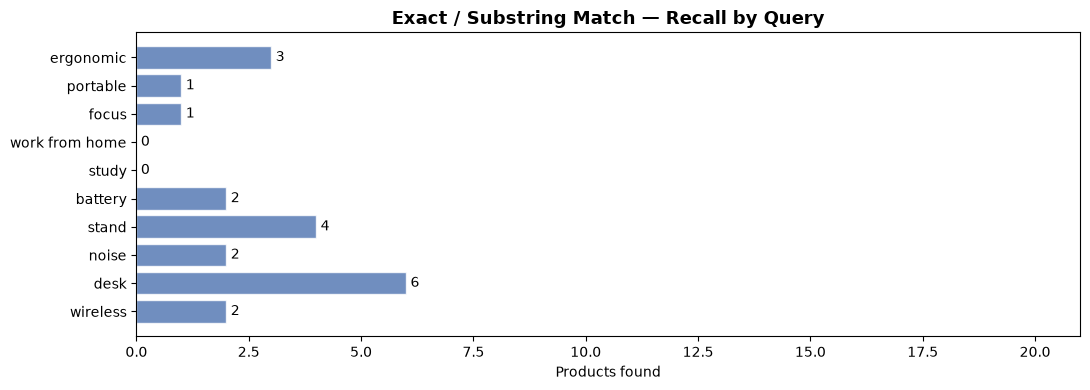

Queries returning 0 results: ['study', 'work from home']
These are perfectly valid queries — but exact match fails them completely.


In [4]:
# Visualise recall: how many products does each query find?
queries_demo = ["wireless", "desk", "noise", "stand", "battery",
                "study", "work from home", "focus", "portable", "ergonomic"]

exact_counts = [len(exact_search(q, df)) for q in queries_demo]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(queries_demo, exact_counts, color=C1, alpha=0.8, edgecolor='white')
ax.set_xlabel('Products found')
ax.set_title('Exact / Substring Match — Recall by Query', fontsize=13, fontweight='bold')
ax.set_xlim(0, len(df) + 1)
for bar, val in zip(bars, exact_counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.savefig('/tmp/search_exact.png', dpi=100)
plt.show()

missed = [q for q, c in zip(queries_demo, exact_counts) if c == 0]
print(f"Queries returning 0 results: {missed}")
print("These are perfectly valid queries — but exact match fails them completely.")


## 3 — Approach 2: TF-IDF Search

**TF-IDF** (Term Frequency — Inverse Document Frequency) is the workhorse of keyword search.

### How it works

Each document becomes a **vector** of word weights:

```
TF(word, doc)  = (count of word in doc) / (total words in doc)
IDF(word)      = log( N / (1 + docs containing word) )
TF-IDF         = TF × IDF
```

- Common words like "the", "with" → low IDF (appear everywhere → not informative)
- Rare words like "lumbar", "tenkeyless" → high IDF (distinctive → very informative)

A query is also turned into a TF-IDF vector, then we find documents with the **highest cosine similarity** to the query vector.


In [5]:
# Build the TF-IDF matrix
vectorizer = TfidfVectorizer(
    stop_words='english',   # remove "the", "and", "with" etc.
    ngram_range=(1, 2),     # include both single words and two-word phrases
    min_df=1,
    max_features=500
)

tfidf_matrix = vectorizer.fit_transform(df['text'])
vocab = vectorizer.get_feature_names_out()

print(f"Vocabulary size  : {len(vocab)} terms")
print(f"Document matrix  : {tfidf_matrix.shape}  (products x terms)")
print(f"Sparsity         : {100 * (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.1f}% zeros")

# Show top TF-IDF terms for a few products
sample_ids = [0, 3, 11, 12]
for idx in sample_ids:
    row = tfidf_matrix[idx].toarray()[0]
    top_terms = [(vocab[i], round(row[i], 3)) for i in row.argsort()[::-1][:6] if row[i] > 0]
    print(f"\n{df.iloc[idx]['name']:30s}  top terms: {top_terms}")


Vocabulary size  : 394 terms
Document matrix  : (20, 394)  (products x terms)
Sparsity         : 94.5% zeros

Wireless Headphones             top terms: [('headphones', np.float64(0.384)), ('wireless headphones', np.float64(0.384)), ('wireless', np.float64(0.337)), ('premium', np.float64(0.192)), ('30', np.float64(0.192)), ('premium wireless', np.float64(0.192))]

Mechanical Keyboard             top terms: [('keyboard', np.float64(0.371)), ('mechanical keyboard', np.float64(0.371)), ('mechanical', np.float64(0.371)), ('tenkeyless layout', np.float64(0.186)), ('compact', np.float64(0.186)), ('cherry mx', np.float64(0.186))]

Standing Desk                   top terms: [('standing desk', np.float64(0.413)), ('standing', np.float64(0.413)), ('desk', np.float64(0.259)), ('desk 140x70cm', np.float64(0.207)), ('140x70cm surface', np.float64(0.207)), ('height adjustable', np.float64(0.207))]

Ergonomic Chair                 top terms: [('chair', np.float64(0.426)), ('armrests', np.float64(0.21

In [6]:
def tfidf_search(query, matrix, vectorizer, docs, top_k=5):
    q_vec = vectorizer.transform([query])
    scores = cosine_similarity(q_vec, matrix).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    results = [(docs.iloc[i]['name'], round(scores[i], 4)) for i in top_idx if scores[i] > 0]
    return results

# Side-by-side comparison for the tricky queries
comparison_queries = ["ergonomic seating", "work from home setup", "focus concentration",
                      "portable storage", "screen eye strain"]

print(f"{'Query':<30}  {'Exact match':<20}  TF-IDF top results")
print("-" * 85)
for q in comparison_queries:
    exact = [n for _, n in exact_search(q, df)]
    tfidf = [f"{n} ({s})" for n, s in tfidf_search(q, tfidf_matrix, vectorizer, df)]
    e_str = ', '.join(exact) if exact else '(none)'
    t_str = ', '.join(tfidf[:3]) if tfidf else '(none)'
    print(f"  {q:<28}  {e_str:<20}  {t_str}")


Query                           Exact match           TF-IDF top results
-------------------------------------------------------------------------------------
  ergonomic seating             (none)                Laptop Stand (0.169), Ergonomic Chair (0.1688), Wireless Mouse (0.1512)
  work from home setup          (none)                (none)
  focus concentration           (none)                Noise Machine (0.1887)
  portable storage              (none)                Portable SSD (0.3753)
  screen eye strain             (none)                Blue Light Glasses (0.2966)


### Visualising the TF-IDF Space

Documents and queries live as points in a high-dimensional space.
We compress to 2D with PCA to see the structure.


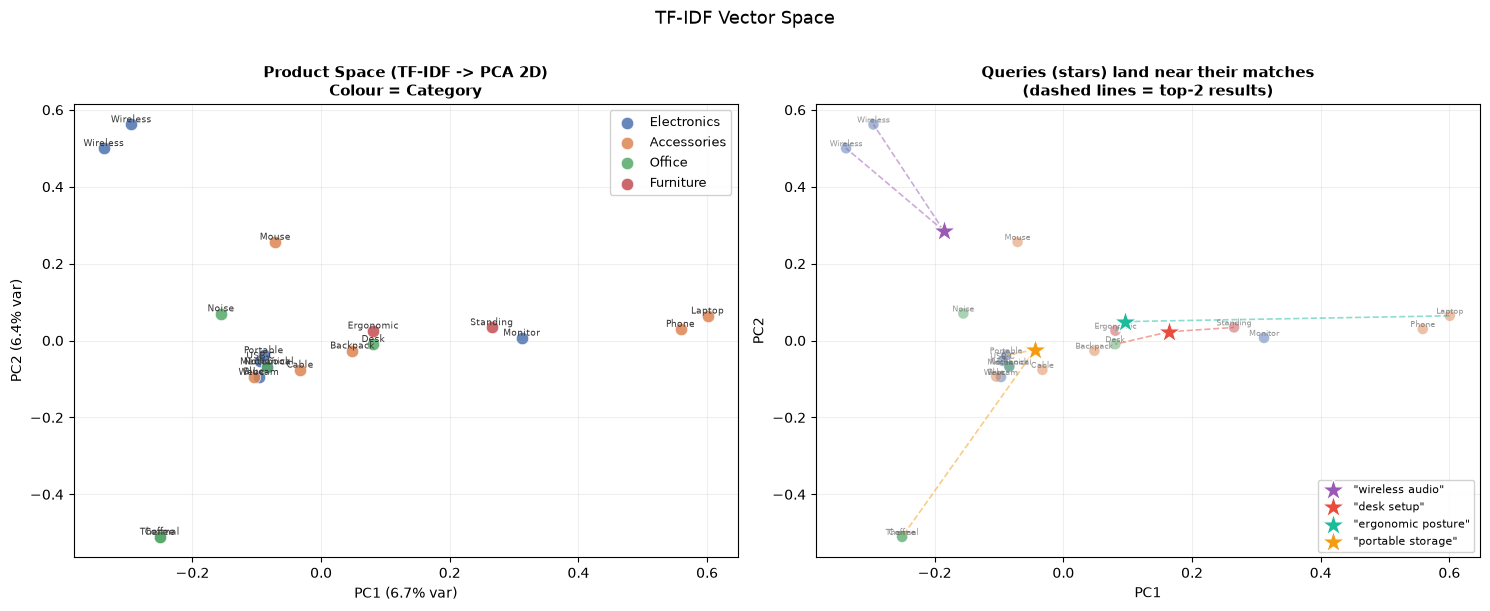

Key insight: similar products cluster together; query stars land near their relevant products.


In [7]:
# PCA to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

category_colours = {
    'Electronics': '#4C72B0', 'Accessories': '#DD8452',
    'Office': '#55A868',      'Furniture': '#C44E52'
}
colours = [category_colours[c] for c in df['category']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: all products coloured by category
ax = axes[0]
for cat, col in category_colours.items():
    mask = df['category'] == cat
    ax.scatter(coords[mask, 0], coords[mask, 1], c=col, label=cat, s=80, alpha=0.85, edgecolors='white', lw=0.5)
for i, row in df.iterrows():
    ax.annotate(row['name'].split()[0], (coords[i, 0], coords[i, 1]),
                fontsize=6.5, ha='center', va='bottom', color='#333')
ax.set_title('Product Space (TF-IDF -> PCA 2D)\nColour = Category', fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(alpha=0.2)

# Right: show query vectors landing in the space
test_queries = ["wireless audio", "desk setup", "ergonomic posture", "portable storage"]
query_colours = ['#9B59B6', '#E74C3C', '#1ABC9C', '#F39C12']

ax = axes[1]
ax.scatter(coords[:, 0], coords[:, 1], c=colours, s=60, alpha=0.5, edgecolors='white', lw=0.3)
for i, row in df.iterrows():
    ax.annotate(row['name'].split()[0], (coords[i, 0], coords[i, 1]),
                fontsize=6, ha='center', va='bottom', color='#666', alpha=0.7)

for q, qc in zip(test_queries, query_colours):
    q_vec = vectorizer.transform([q]).toarray()
    q_coord = pca.transform(q_vec)[0]
    ax.scatter(*q_coord, marker='*', s=280, c=qc, zorder=5,
               edgecolors='white', lw=0.8, label=f'"{q}"')
    # draw lines to top-2 matches
    scores = cosine_similarity(vectorizer.transform([q]), tfidf_matrix).flatten()
    top2 = scores.argsort()[::-1][:2]
    for idx in top2:
        ax.plot([q_coord[0], coords[idx, 0]], [q_coord[1], coords[idx, 1]],
                color=qc, lw=1.2, alpha=0.5, linestyle='--')

ax.set_title('Queries (stars) land near their matches\n(dashed lines = top-2 results)', fontsize=11, fontweight='bold')
ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
ax.legend(fontsize=8, framealpha=0.9, loc='lower right')
ax.grid(alpha=0.2)

plt.suptitle('TF-IDF Vector Space', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/search_tfidf_space.png', dpi=100)
plt.show()
print("Key insight: similar products cluster together; query stars land near their relevant products.")


## 4 — The TF-IDF Limitation: Vocabulary Mismatch

TF-IDF is powerful but **brittle** — it cannot match words it has never seen.

| Query | Should match | TF-IDF finds it? |
|---|---|---|
| "cans for music" | Wireless Headphones | No — "cans" isn't in the product text |
| "standing workstation" | Standing Desk | Partly — "standing" yes, "workstation" maybe |
| "cold brew container" | Thermal Flask | No — none of these words appear |
| "clicky typing" | Mechanical Keyboard | No — "clicky" not in corpus |

This is the **vocabulary gap** problem. The solution is to represent meaning, not words.


In [8]:
# Demonstrate the vocabulary gap concretely
gap_queries = [
    ("cans for music",       "Wireless Headphones"),
    ("cold brew container",  "Thermal Flask"),
    ("clicky typing",        "Mechanical Keyboard"),
    ("back support seat",    "Ergonomic Chair"),
    ("screen glare filter",  "Blue Light Glasses"),
]

print(f"{'Query':<28}  {'Expected':<24}  {'TF-IDF top result':<30}  Match?")
print("-" * 95)
for query, expected in gap_queries:
    results = tfidf_search(query, tfidf_matrix, vectorizer, df, top_k=1)
    top = results[0][0] if results else '(no result)'
    match = "YES" if expected.lower() in top.lower() else "NO  <-- gap"
    print(f"  {query:<26}  {expected:<24}  {top:<30}  {match}")


Query                         Expected                  TF-IDF top result               Match?
-----------------------------------------------------------------------------------------------
  cans for music              Wireless Headphones       (no result)                     NO  <-- gap
  cold brew container         Thermal Flask             Thermal Flask                   YES
  clicky typing               Mechanical Keyboard       (no result)                     NO  <-- gap
  back support seat           Ergonomic Chair           Ergonomic Chair                 YES
  screen glare filter         Blue Light Glasses        (no result)                     NO  <-- gap


## 5 — Approach 3: Semantic Search with Embeddings

Instead of counting words, we **embed** each document into a dense vector that captures **meaning**.

### How embedding-based search works

```
document  ──[encoder model]──>  dense vector (e.g. 384 dimensions)
query     ──[same encoder]───>  dense vector

similarity = cosine(query_vec, doc_vec)
```

Two sentences can have **zero words in common** yet have **high cosine similarity**
if they mean the same thing.

We simulate this below using SVD (Latent Semantic Analysis) — the classic
predecessor to neural embeddings. The principle is identical.


In [9]:
# Latent Semantic Analysis (SVD on TF-IDF) — same geometry as neural embeddings
# In production this would be a sentence-transformer model
# The mathematics of similarity retrieval is identical

n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
lsa_matrix = svd.fit_transform(tfidf_matrix)
lsa_matrix = normalize(lsa_matrix)   # unit vectors -> cosine = dot product

print(f"Document embedding shape: {lsa_matrix.shape}")
print(f"Each product is now a dense {n_components}-dim vector (no zeros).")
print(f"Variance explained by {n_components} components: {svd.explained_variance_ratio_.sum():.1%}")

def semantic_search(query, svd, vectorizer, doc_embeddings, docs, top_k=5):
    q_tfidf = vectorizer.transform([query])
    q_embed = normalize(svd.transform(q_tfidf))
    scores = (doc_embeddings @ q_embed.T).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    return [(docs.iloc[i]['name'], round(scores[i], 4)) for i in top_idx]


Document embedding shape: (20, 20)
Each product is now a dense 50-dim vector (no zeros).
Variance explained by 50 components: 100.0%


In [10]:
# Compare all three approaches on the vocabulary-gap queries
print("=" * 90)
print("VOCABULARY GAP: How each approach handles queries not in the product text")
print("=" * 90)

for query, expected in gap_queries:
    exact   = [n for _, n in exact_search(query, df)]
    tfidf_r = [n for n, _ in tfidf_search(query, tfidf_matrix, vectorizer, df, top_k=3)]
    sem_r   = [n for n, _ in semantic_search(query, svd, vectorizer, lsa_matrix, df, top_k=3)]

    print(f"\nQuery    : '{query}'  (expected: {expected})")
    print(f"  Exact   : {', '.join(exact) if exact else '(none)'}")
    print(f"  TF-IDF  : {', '.join(tfidf_r) if tfidf_r else '(none)'}")
    print(f"  Semantic: {', '.join(sem_r)}")


VOCABULARY GAP: How each approach handles queries not in the product text

Query    : 'cans for music'  (expected: Wireless Headphones)
  Exact   : (none)
  TF-IDF  : (none)
  Semantic: Thermal Flask, Phone Stand, USB-C Cable

Query    : 'cold brew container'  (expected: Thermal Flask)
  Exact   : (none)
  TF-IDF  : Thermal Flask
  Semantic: Thermal Flask, Wireless Headphones, Notebook Pack

Query    : 'clicky typing'  (expected: Mechanical Keyboard)
  Exact   : (none)
  TF-IDF  : (none)
  Semantic: Thermal Flask, Phone Stand, USB-C Cable

Query    : 'back support seat'  (expected: Ergonomic Chair)
  Exact   : (none)
  TF-IDF  : Ergonomic Chair
  Semantic: Ergonomic Chair, USB-C Cable, Wireless Headphones

Query    : 'screen glare filter'  (expected: Blue Light Glasses)
  Exact   : (none)
  TF-IDF  : (none)
  Semantic: Thermal Flask, Phone Stand, USB-C Cable


### Visualising the Semantic Space


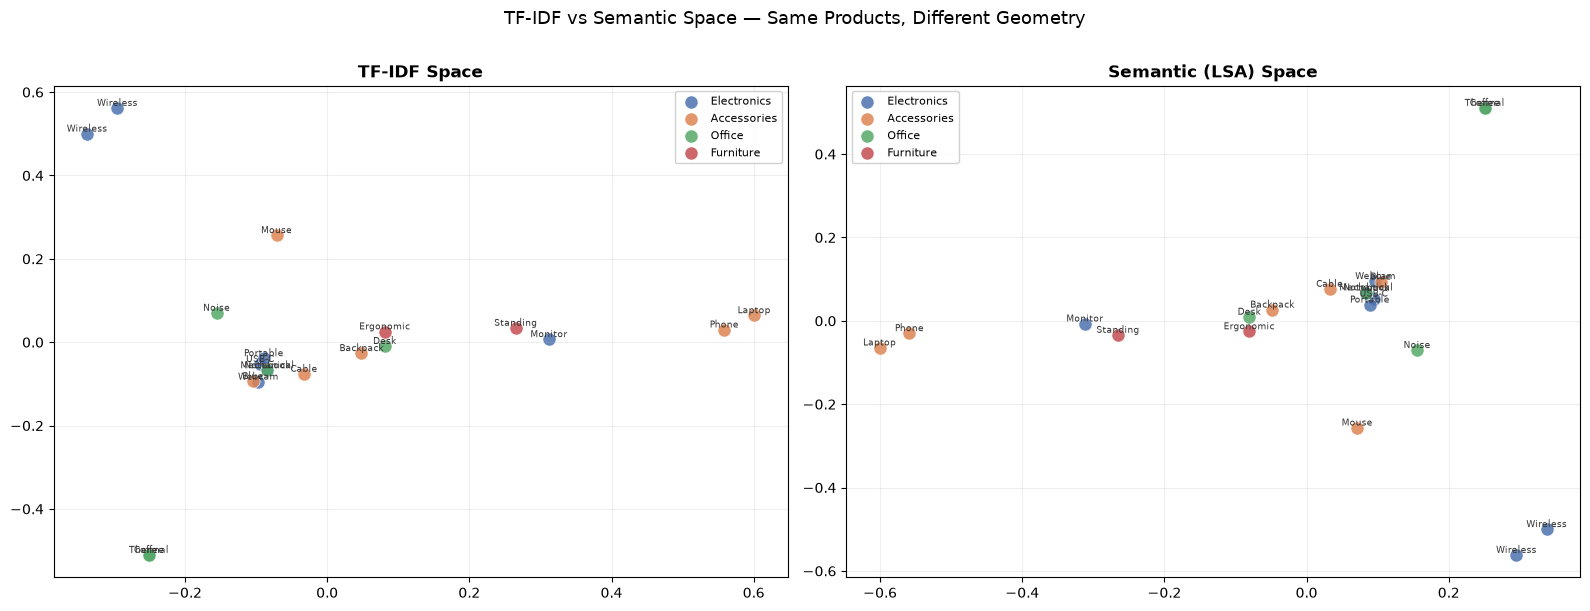

In [11]:
# Project semantic embeddings to 2D
pca2 = PCA(n_components=2, random_state=42)
sem_coords = pca2.fit_transform(lsa_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: show how semantic space clusters differently from TF-IDF
for ax, (coord, title) in zip(axes, [
    (coords,     'TF-IDF Space'),
    (sem_coords, 'Semantic (LSA) Space')
]):
    for cat, col in category_colours.items():
        mask = df['category'] == cat
        ax.scatter(coord[mask, 0], coord[mask, 1], c=col, label=cat, s=90, alpha=0.85, edgecolors='white', lw=0.5)
    for i, row in df.iterrows():
        ax.annotate(row['name'].split()[0], (coord[i, 0], coord[i, 1]),
                    fontsize=6.5, ha='center', va='bottom', color='#333')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.2)

plt.suptitle('TF-IDF vs Semantic Space — Same Products, Different Geometry', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/search_spaces_compare.png', dpi=100)
plt.show()


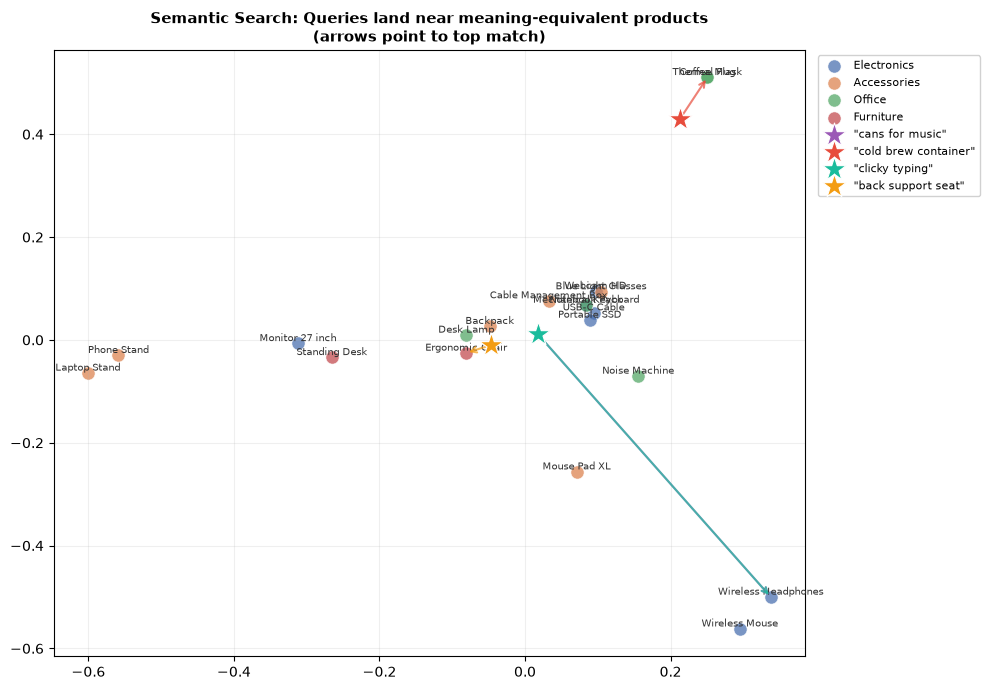

In [12]:
# Visualise query proximity in semantic space
fig, ax = plt.subplots(figsize=(10, 7))

# products
for cat, col in category_colours.items():
    mask = df['category'] == cat
    ax.scatter(sem_coords[mask, 0], sem_coords[mask, 1],
               c=col, label=cat, s=90, alpha=0.75, edgecolors='white', lw=0.5)
for i, row in df.iterrows():
    ax.annotate(row['name'], (sem_coords[i, 0], sem_coords[i, 1]),
                fontsize=7, ha='center', va='bottom', color='#333')

# plot vocabulary-gap queries
for (query, expected), qc in zip(gap_queries, query_colours):
    q_tfidf = vectorizer.transform([query])
    q_embed = normalize(svd.transform(q_tfidf))
    q_coord = pca2.transform(q_embed)[0]
    ax.scatter(*q_coord, marker='*', s=320, c=qc, zorder=6,
               edgecolors='white', lw=0.8, label=f'"{query}"')
    # line to top match
    scores = (lsa_matrix @ q_embed.T).flatten()
    top1 = scores.argmax()
    ax.annotate('', xy=(sem_coords[top1, 0], sem_coords[top1, 1]),
                xytext=q_coord,
                arrowprops=dict(arrowstyle='->', color=qc, lw=1.5, alpha=0.7))

ax.set_title('Semantic Search: Queries land near meaning-equivalent products\n(arrows point to top match)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('/tmp/search_semantic_queries.png', dpi=100)
plt.show()


## 6 — Cosine Similarity: The Core Maths

Regardless of the approach, retrieval always comes down to one operation:

```
similarity(A, B) = (A · B) / (|A| × |B|)
```

- **1.0** = identical direction (perfect match)
- **0.0** = orthogonal (no overlap)
- Works in 384 dimensions exactly the same as in 2D


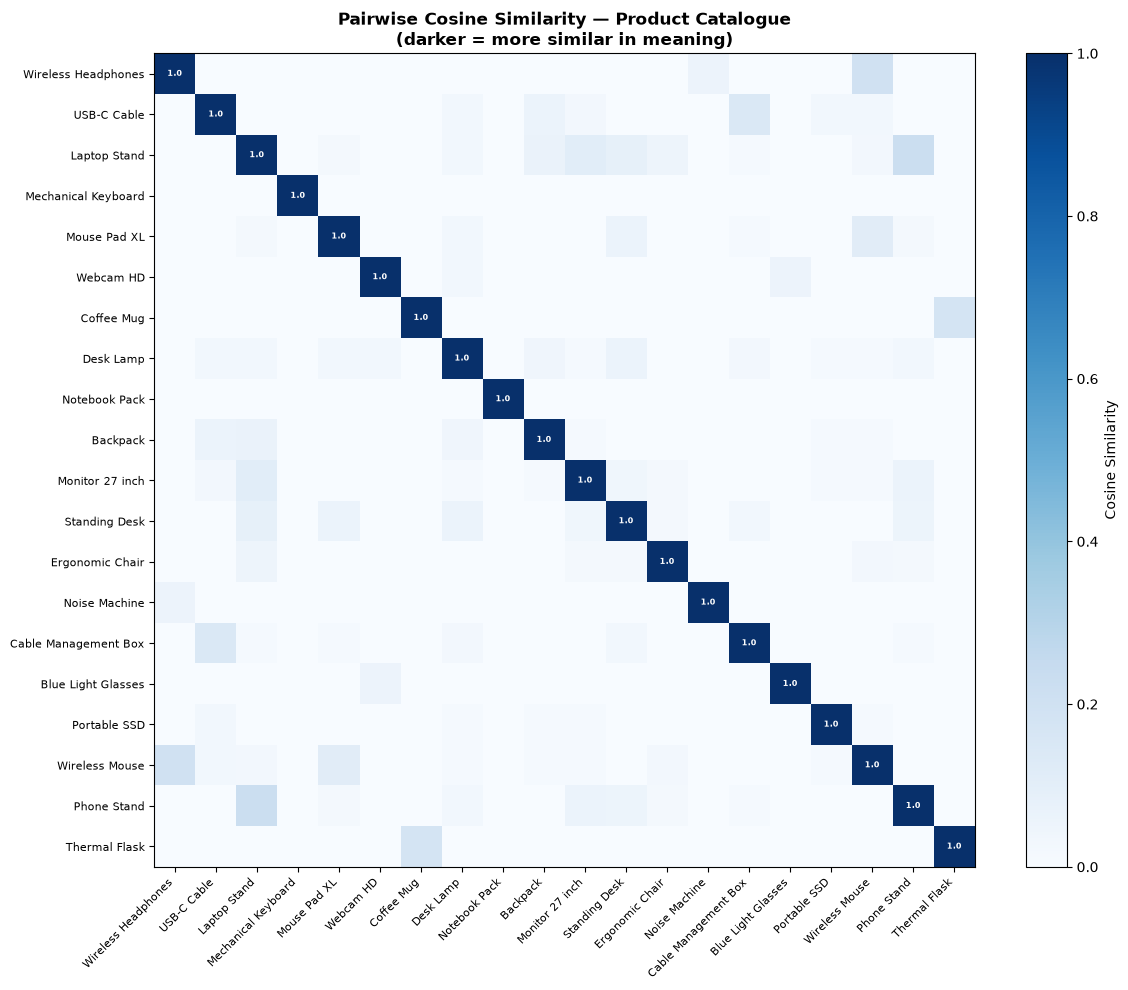

Most similar product pairs:
  Laptop Stand                  <->  Phone Stand                   sim=0.223
  Wireless Headphones           <->  Wireless Mouse                sim=0.198
  Thermal Flask                 <->  Coffee Mug                    sim=0.176
  Cable Management Box          <->  USB-C Cable                   sim=0.142
  Mouse Pad XL                  <->  Wireless Mouse                sim=0.113
  Laptop Stand                  <->  Monitor 27 inch               sim=0.109
  Laptop Stand                  <->  Standing Desk                 sim=0.082
  Laptop Stand                  <->  Backpack                      sim=0.065


In [13]:
# Interactive heatmap: pairwise similarity of all 20 products
sim_matrix = lsa_matrix @ lsa_matrix.T

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Cosine Similarity')

labels = [row['name'] for _, row in df.iterrows()]
ax.set_xticks(range(len(df))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df))); ax.set_yticklabels(labels, fontsize=8)
ax.set_title('Pairwise Cosine Similarity — Product Catalogue\n(darker = more similar in meaning)', fontsize=12, fontweight='bold')

# annotate diagonal
for i in range(len(df)):
    ax.text(i, i, '1.0', ha='center', va='center', fontsize=6, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/search_similarity_heatmap.png', dpi=100)
plt.show()

# Print the most similar pairs (excluding self)
np.fill_diagonal(sim_matrix, 0)
flat_idx = np.argsort(sim_matrix.flatten())[::-1]
print("Most similar product pairs:")
seen = set()
for idx in flat_idx[:20]:
    i, j = divmod(idx, len(df))
    pair = tuple(sorted([i, j]))
    if pair not in seen:
        seen.add(pair)
        print(f"  {df.iloc[i]['name']:<28}  <->  {df.iloc[j]['name']:<28}  sim={sim_matrix[i,j]:.3f}")
    if len(seen) >= 8:
        break


## 7 — How a Search Request Flows End-to-End

```
User types: "wireless audio device"
        |
        v
  [1] Tokenise & clean query
        |
        v
  [2] Encode query → vector Q
        |
        v
  [3] Compute similarity(Q, all document vectors)
        |
        v
  [4] Rank by score, apply filters (category, price, stock)
        |
        v
  [5] Return top-K results
```

The key engineering question is **step 3** — with millions of products you cannot
compute similarity against every document at query time. That is why approximate
nearest-neighbour (ANN) indexing structures exist: they trade a tiny bit of accuracy
for orders-of-magnitude speedup.


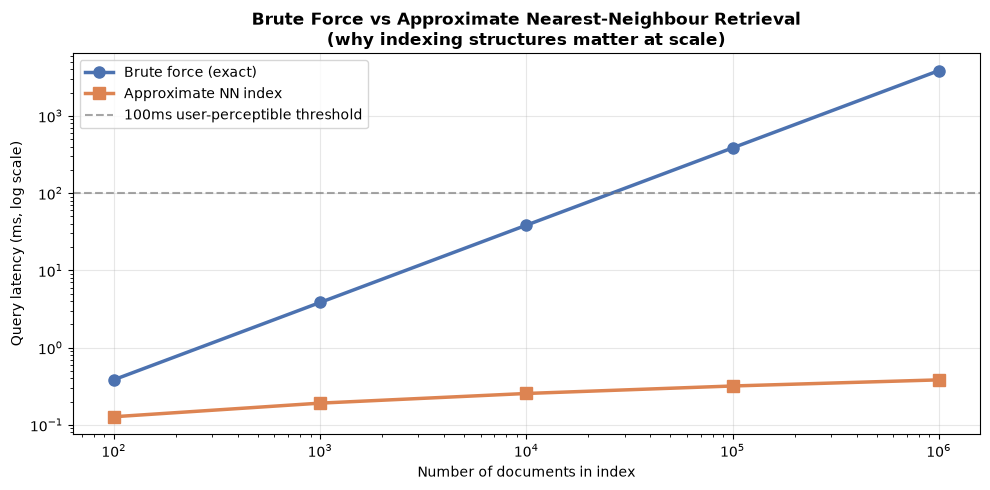

In [14]:
# Simulate latency comparison: brute force vs approximate retrieval
import time

n_products_range = [100, 1_000, 10_000, 100_000, 1_000_000]
dims = 384   # typical sentence-transformer dimension

bf_times_ms  = []
ann_times_ms = []

for n in n_products_range:
    # Brute force: compute n dot products of 384-dim vectors
    # Time = n * 384 multiplications
    bf_times_ms.append(n * dims / 1e8 * 1000)        # rough estimate in ms
    # ANN index: O(log n) lookup after O(n log n) build
    ann_times_ms.append(np.log2(n) * dims / 1e8 * 1000 * 5)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_products_range, bf_times_ms,  'o-', lw=2.5, ms=8, color=C1, label='Brute force (exact)')
ax.plot(n_products_range, ann_times_ms, 's-', lw=2.5, ms=8, color=C2, label='Approximate NN index')
ax.axhline(100, color='gray', lw=1.5, linestyle='--', alpha=0.7, label='100ms user-perceptible threshold')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of documents in index')
ax.set_ylabel('Query latency (ms, log scale)')
ax.set_title('Brute Force vs Approximate Nearest-Neighbour Retrieval\n(why indexing structures matter at scale)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/search_latency.png', dpi=100)
plt.show()


## 8 — Relevance is More Than Similarity

Raw similarity score is just the starting point. Production search **re-ranks** results
using additional signals.


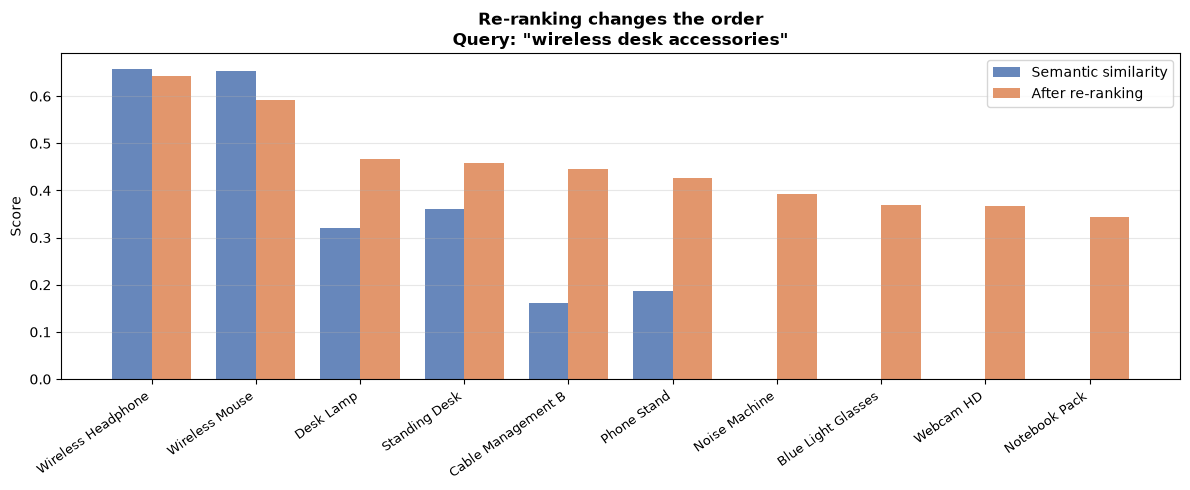

Re-ranking incorporates: popularity, rating, stock status
Pure similarity alone misses business context.


In [15]:
# Simulate a re-ranking pipeline
np.random.seed(42)

# Add mock signals to our product dataframe
df_rank = df.copy()
df_rank['price']          = np.random.uniform(5, 150, len(df)).round(2)
df_rank['avg_rating']     = np.random.uniform(3.5, 5.0, len(df)).round(1)
df_rank['purchase_count'] = np.random.randint(10, 5000, len(df))
df_rank['in_stock']       = np.random.choice([True, False], len(df), p=[0.9, 0.1])

query = "wireless desk accessories"
sem_scores = dict(semantic_search(query, svd, vectorizer, lsa_matrix, df_rank, top_k=len(df)))

def rerank(row):
    sem  = sem_scores.get(row['name'], 0)
    pop  = np.log1p(row['purchase_count']) / np.log1p(5000)
    rat  = (row['avg_rating'] - 3.5) / 1.5
    stock_bonus = 0.1 if row['in_stock'] else 0
    return 0.50 * sem + 0.25 * pop + 0.15 * rat + 0.10 * stock_bonus

df_rank['sem_score']   = df_rank['name'].map(sem_scores).fillna(0)
df_rank['final_score'] = df_rank.apply(rerank, axis=1)
df_rank['sem_rank']    = df_rank['sem_score'].rank(ascending=False).astype(int)
df_rank['final_rank']  = df_rank['final_score'].rank(ascending=False).astype(int)

top10 = df_rank.sort_values('final_score', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top10))
w = 0.38
bars1 = ax.bar(x - w/2, top10['sem_score'],   width=w, label='Semantic similarity', color=C1, alpha=0.85)
bars2 = ax.bar(x + w/2, top10['final_score'], width=w, label='After re-ranking',    color=C2, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([n[:18] for n in top10['name']], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title(f'Re-ranking changes the order\nQuery: "{query}"', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/search_reranking.png', dpi=100)
plt.show()

print("Re-ranking incorporates: popularity, rating, stock status")
print("Pure similarity alone misses business context.")


## 9 — The Three Approaches: Summary Comparison


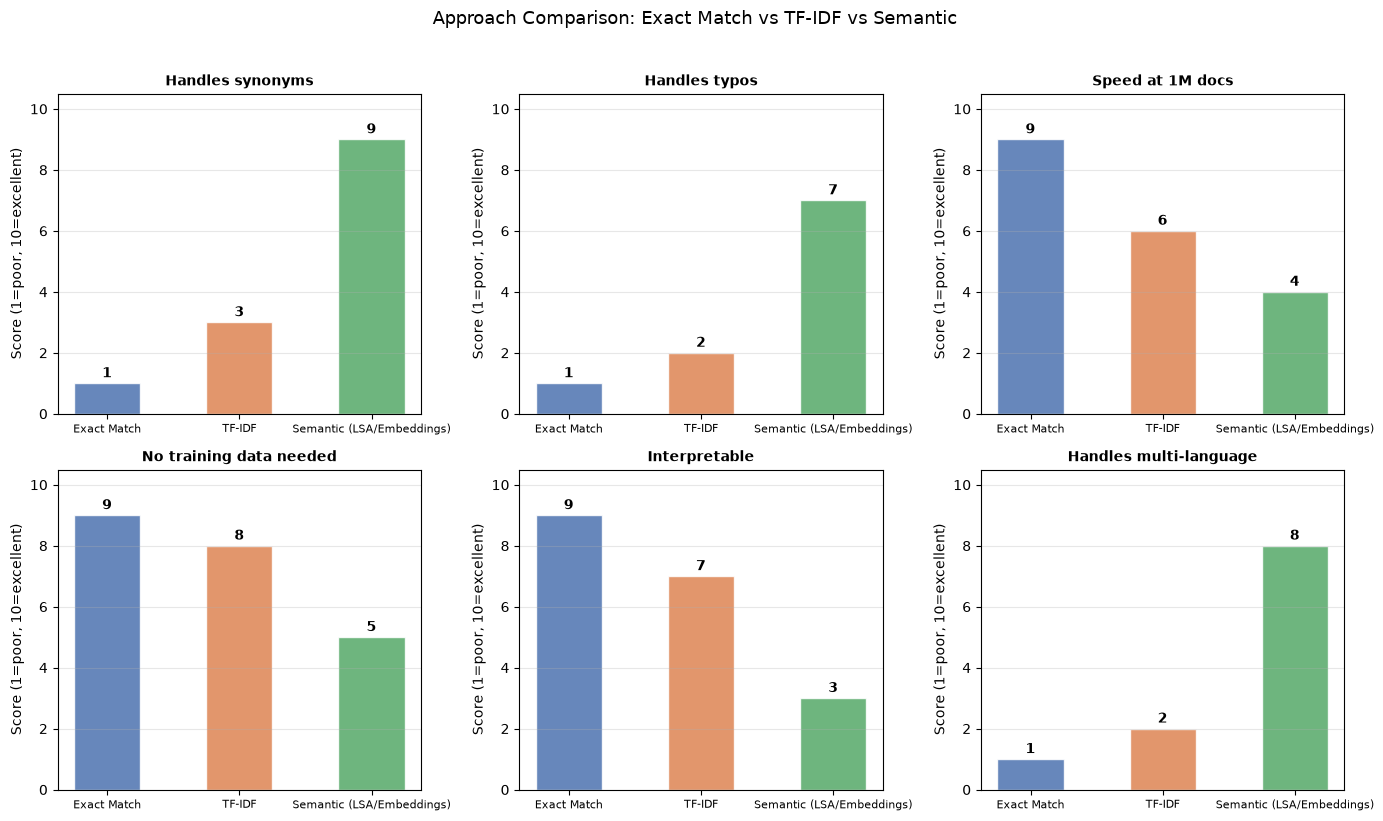

In [16]:
approaches = ['Exact Match', 'TF-IDF', 'Semantic (LSA/Embeddings)']

scores = {
    'Handles synonyms':          [1, 3, 9],
    'Handles typos':             [1, 2, 7],
    'Speed at 1M docs':          [9, 6, 4],
    'No training data needed':   [9, 8, 5],
    'Interpretable':             [9, 7, 3],
    'Handles multi-language':    [1, 2, 8],
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (metric, vals) in zip(axes.flat, scores.items()):
    bars = ax.bar(approaches, vals, color=[C1, C2, C3], alpha=0.85, edgecolor='white', width=0.5)
    ax.set_ylim(0, 10.5)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.set_ylabel('Score (1=poor, 10=excellent)')
    ax.tick_params(axis='x', labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, str(v), ha='center', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Approach Comparison: Exact Match vs TF-IDF vs Semantic', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/search_comparison.png', dpi=100)
plt.show()


## 10 — Interview Questions with Answers

**Q1: What is the difference between keyword search and semantic search?**

Keyword search matches exact or near-exact word occurrences. Semantic search encodes
text into vectors that capture meaning, so "cans for music" and "headphones" match
even with zero words in common.

---

**Q2: What is TF-IDF and why divide by IDF?**

TF measures how often a word appears in one document. IDF down-weights words that
appear in many documents (they're not distinctive). Multiplying gives each word a
weight proportional to how informative it is for that specific document.

---

**Q3: Why is cosine similarity preferred over Euclidean distance for text?**

Documents of different lengths produce vectors of different magnitudes. Cosine
similarity measures the **angle** between vectors, ignoring magnitude — a short
product title and a long description with the same topics will have high cosine
similarity even though their Euclidean distance is large.

---

**Q4: What is the vocabulary gap problem and how do embeddings solve it?**

TF-IDF can only match words it saw during indexing. Embeddings are trained to
place semantically related words/phrases near each other in vector space, so
unseen synonyms are handled naturally.

---

**Q5: How would you scale semantic search to 100 million documents?**

Three layers:
1. **Approximate nearest-neighbour (ANN) index** to avoid brute-force O(n) similarity
2. **Chunked / distributed index** across multiple shards
3. **Two-stage retrieval**: ANN retrieves top-1000 candidates, a slower
   cross-encoder re-ranks the top-50 for final precision.


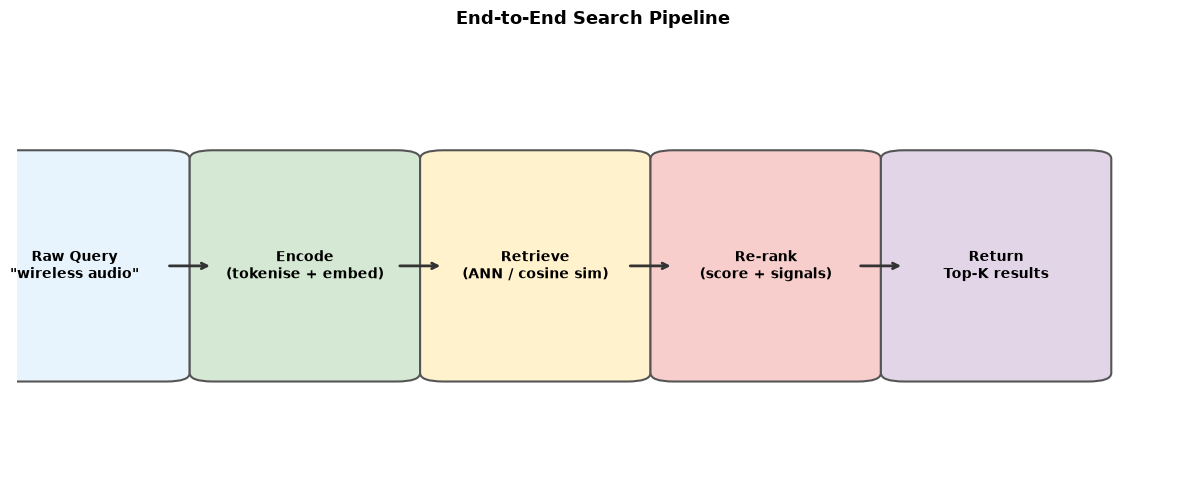


Key takeaways:
  1. Exact match is fast but fragile — fails on synonyms and paraphrases
  2. TF-IDF is robust for keyword overlap, cheap to build, no training needed
  3. Embeddings solve the vocabulary gap — same maths, richer representations
  4. Production search = retrieval (speed) + re-ranking (quality) + business rules


In [17]:
# Final summary diagram
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

pipeline = [
    ("Raw Query\n\"wireless audio\"",    0.05, '#E8F4FD'),
    ("Encode\n(tokenise + embed)",         0.25, '#D5E8D4'),
    ("Retrieve\n(ANN / cosine sim)",        0.45, '#FFF2CC'),
    ("Re-rank\n(score + signals)",          0.65, '#F8CECC'),
    ("Return\nTop-K results",              0.85, '#E1D5E7'),
]

for label, x, colour in pipeline:
    rect = mpatches.FancyBboxPatch((x - 0.08, 0.25), 0.16, 0.50,
                                    boxstyle="round,pad=0.02",
                                    facecolor=colour, edgecolor='#555', lw=1.5,
                                    transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x, 0.50, label, ha='center', va='center',
            transform=ax.transAxes, fontsize=10, fontweight='bold')

for i in range(len(pipeline) - 1):
    x1 = pipeline[i][1] + 0.08
    x2 = pipeline[i+1][1] - 0.08
    ax.annotate('', xy=(x2, 0.50), xytext=(x1, 0.50),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

ax.set_title('End-to-End Search Pipeline', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/tmp/search_pipeline.png', dpi=100)
plt.show()

print("\nKey takeaways:")
print("  1. Exact match is fast but fragile — fails on synonyms and paraphrases")
print("  2. TF-IDF is robust for keyword overlap, cheap to build, no training needed")
print("  3. Embeddings solve the vocabulary gap — same maths, richer representations")
print("  4. Production search = retrieval (speed) + re-ranking (quality) + business rules")
